# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [26]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [27]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    cols_with_nans = df.columns[df.isnull().any()]
    print("Stats before imputation:")
    print(df[cols_with_nans].agg(['median', 'std'])) 
    
    imputer = KNNImputer(n_neighbors=5) 
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    
    print("\nStats after imputation:")
    print(df[cols_with_nans].agg(['median', 'std']))
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

Stats before imputation:
        SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  BranchLength
median       6.300000      2.900000       5.085612      1.600000     16.300000
std          1.037115      0.389564       1.582807      0.706689      1.035228

Stats after imputation:
        SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  BranchLength
median       6.300000      2.900000       5.035683      1.700000     16.300000
std          1.009275      0.372434       1.514955      0.694645      1.011012


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

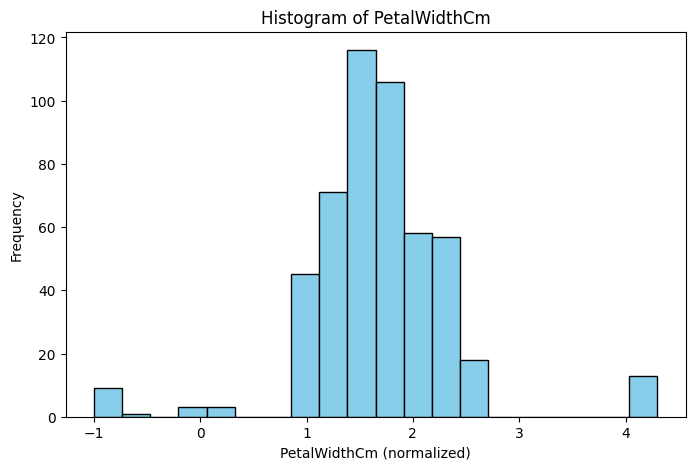

4(b) Feature with largest positive correlation: PetalWidthCompactness(0.9917)

4(c) Top 5 features with strongest negative correlations:
SepalWidthMajorAxis     -0.096350
SepalGlossIndex         -0.095200
SepalWidthCompactness   -0.088496
SepalWidthCurvature     -0.081334
SepalWidthMinorAxis     -0.074392
dtype: float64


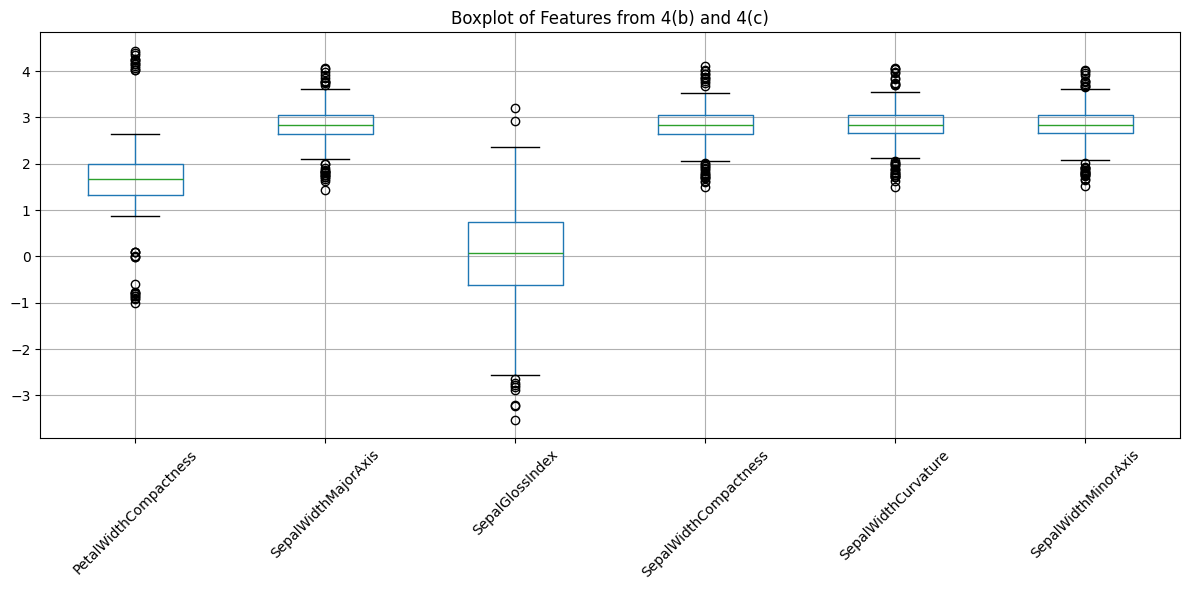

In [5]:
from sklearn.feature_selection import r_regression
import seaborn as sns


# --- 4a. Histogram von PetalWidthCm ---
plt.figure(figsize=(8, 5))
plt.hist(df['PetalWidthCm'], bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of PetalWidthCm")
plt.xlabel("PetalWidthCm (normalized)")
plt.ylabel("Frequency")

plt.show()
   
# Beschreibung (für dein Dokument): 
# Die Verteilung zeigt oft zwei deutliche Cluster (bimodal), 
# was auf die Trennung der verschiedenen Iris-Arten hindeutet.
   
# --- Vorbereitung für 4b & 4c ---
# Wir schließen 'PetalWidthCm', 'Species' und 'Id' aus den Features aus
exploration_cols = [c for c in feature_cols if c not in ['PetalWidthCm', 'Id','Species']]
   
# Korrelation von allen anderen Features zu 'PetalWidthCm' berechnen
corrs = r_regression(df[exploration_cols], df['PetalWidthCm'])
corr_series = pd.Series(corrs, index=exploration_cols)
   
# --- 4b. Größte positive Korrelation ---
max_pos_feature = corr_series.idxmax()
print(f"4(b) Feature with largest positive correlation: {max_pos_feature}({corr_series.max():.4f})")
   
# --- 4c. Top 5 stärkste negative Korrelationen ---
top_5_neg = corr_series.sort_values(ascending=True).head(5)
print("\n4(c) Top 5 features with strongest negative correlations:")
print(top_5_neg)
   
# --- 4d. Boxplot für die gefundenen Features ---
selected_features = [max_pos_feature] + list(top_5_neg.index)
plt.figure(figsize=(12, 6))
df[selected_features].boxplot()
plt.title("Boxplot of Features from 4(b) and 4(c)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Model Training

### Prepare the data

In [6]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6183968442308058, Val loss:0.6383418749174559
100. Training loss: 0.5960218584459506, Val loss:0.6229937284988915
150. Training loss: 0.5781987940557217, Val loss:0.6111917862872271
200. Training loss: 0.5636852669117252, Val loss:0.6019940821319419
250. Training loss: 0.5516390786456719, Val loss:0.5947528491389575
300. Training loss: 0.5414760921827046, Val loss:0.5890110215795246
350. Training loss: 0.5327814781753895, Val loss:0.5844381571451083
400. Training loss: 0.5252538055110114, Val loss:0.5807900103412457
450. Training loss: 0.5186692635109195, Val loss:0.5778824491950174
500. Training loss: 0.5128583316269498, Val loss:0.5755742266452544
550. Training loss: 0.5076902593666242, Val loss:0.5737553335810299
600. Training loss: 0.5030625328026355, Val loss:0.5723389483402411
650. Training loss: 0.4988935840888995, Val loss:0.5712557548145529
700. Training loss: 0.4951176496280415, Val loss:0.5704498539888323
750. Training loss: 0.4916810781087383, Val loss:

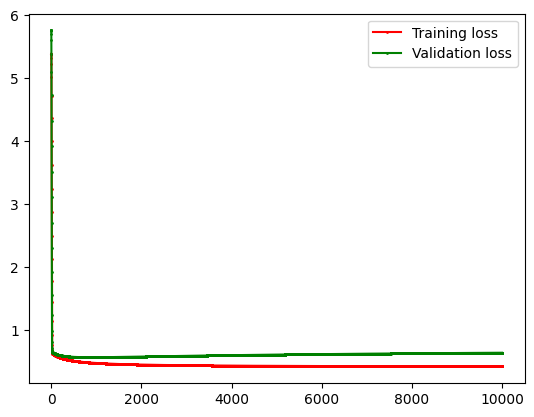

Model parameters (weights): [[-2.97876505]
 [ 0.81130731]
 [ 0.35528897]
 [-0.73679613]
 [ 0.87659738]
 [ 0.00714037]
 [ 0.29226848]
 [-0.01772541]
 [ 0.20894927]
 [ 1.82921786]
 [ 0.85907033]
 [ 0.72379246]
 [ 1.13860011]
 [ 0.18023064]
 [-0.98074977]
 [-0.08251054]
 [ 1.54000897]
 [ 0.68242964]
 [ 0.1607335 ]
 [ 0.17939641]
 [ 0.27374655]
 [ 0.49310344]
 [-0.09550356]
 [ 0.64472868]
 [ 0.41315937]
 [ 2.01483644]
 [ 1.73912209]
 [ 1.7167826 ]
 [ 1.96135615]
 [ 1.78457872]
 [ 1.74015759]
 [-2.2200224 ]
 [ 1.38375193]
 [-0.38485774]
 [ 0.2569879 ]
 [-1.44347253]
 [ 0.58870085]
 [-1.07510967]
 [-2.96865714]
 [-0.4420989 ]
 [-1.20536784]
 [-0.42415863]
 [-0.95640275]
 [-1.21105373]
 [ 0.50705798]
 [-0.04846362]
 [ 0.00309922]
 [ 0.27501913]
 [-0.59831019]
 [-0.66043573]
 [-0.46393957]
 [ 0.3174146 ]
 [ 0.16453656]
 [-0.58687953]
 [-0.38301178]
 [ 0.46861583]
 [-0.84259829]
 [-1.20525122]
 [-0.2997417 ]
 [ 0.53205457]
 [-0.99486234]
 [ 0.72265591]
 [ 0.60878032]
 [-1.57244871]
 [ 0.1224894

In [23]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=0.01)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

=== Model Evaluation ===
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


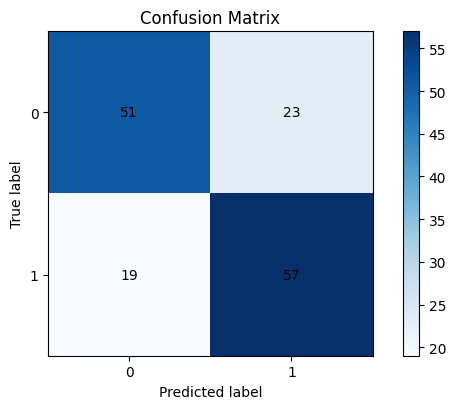

{'Accuracy': 0.72,
 'Precision': 0.7125,
 'Recall': 0.75,
 'F1-score': 0.7307692307692307}

In [24]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)